In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
ERROR_PATH = "../reports/error_analysis.csv"
FIGURE_DIR = "../reports/figures"

os.makedirs(FIGURE_DIR, exist_ok=True)

error_df = pd.read_csv(ERROR_PATH)

error_df.head()

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,Actual_FloodProbability,Predicted_FloodProbability,Error,Absolute_Error
0,4,7,5,7,4,5,8,2,6,4,...,1,4,3,3,3,9,0.285,0.466359,0.181359,0.181359
1,6,2,2,5,7,4,5,3,6,4,...,8,6,5,3,3,5,0.285,0.466139,0.181139,0.181139
2,8,7,0,5,9,6,4,7,3,8,...,3,7,5,7,0,6,0.695,0.516892,-0.178108,0.178108
3,4,5,3,5,6,5,6,5,2,5,...,7,2,3,3,6,7,0.285,0.460650,0.175650,0.175650
4,7,4,3,7,4,3,10,4,6,2,...,6,4,5,2,4,4,0.285,0.460558,0.175558,0.175558


In [4]:
print("Shape:", error_df.shape)

print("\nColumns:")
for col in error_df.columns:
    print(col)

Shape: (223592, 24)

Columns:
MonsoonIntensity
TopographyDrainage
RiverManagement
Deforestation
Urbanization
ClimateChange
DamsQuality
Siltation
AgriculturalPractices
Encroachments
IneffectiveDisasterPreparedness
DrainageSystems
CoastalVulnerability
Landslides
Watersheds
DeterioratingInfrastructure
PopulationScore
WetlandLoss
InadequatePlanning
PoliticalFactors
Actual_FloodProbability
Predicted_FloodProbability
Error
Absolute_Error


In [5]:
error_summary = error_df[
    [
        "Actual_FloodProbability",
        "Predicted_FloodProbability",
        "Error",
        "Absolute_Error"
    ]
].describe()

error_summary

,Actual_FloodProbability,Predicted_FloodProbability,Error,Absolute_Error
count,223592.000000,223592.000000,223592.000000,2.235920e+05
mean,0.504481,0.504455,-0.000026,1.579248e-02
std,0.050983,0.046872,0.020080,1.240181e-02
min,0.285000,0.302500,-0.178108,5.676990e-08
25%,0.470000,0.476952,-0.011240,8.154672e-03
50%,0.505000,0.499999,0.004697,1.195770e-02
75%,0.540000,0.534092,0.012166,2.201469e-02
max,0.725000,0.754241,0.181359,1.813595e-01


In [6]:
big_errors = error_df.sort_values("Absolute_Error", ascending=False).head(20)

big_errors[
    [
        "Actual_FloodProbability",
        "Predicted_FloodProbability",
        "Error",
        "Absolute_Error"
    ]
]

,Actual_FloodProbability,Predicted_FloodProbability,Error,Absolute_Error
0,0.285,0.466359,0.181359,0.181359
1,0.285,0.466139,0.181139,0.181139
2,0.695,0.516892,-0.178108,0.178108
3,0.285,0.460650,0.175650,0.175650
4,0.285,0.460558,0.175558,0.175558
5,0.685,0.516818,-0.168182,0.168182
6,0.460,0.347537,-0.112463,0.112463
7,0.725,0.612651,-0.112349,0.112349
8,0.445,0.551076,0.106076,0.106076
9,0.435,0.539488,0.104488,0.104488


In [7]:
TOP_ERRORS_PATH = "../reports/top_20_errors.csv"

big_errors.to_csv(TOP_ERRORS_PATH, index=False)

print(f"Top 20 errors saved to: {TOP_ERRORS_PATH}")

Top 20 errors saved to: ../reports/top_20_errors.csv


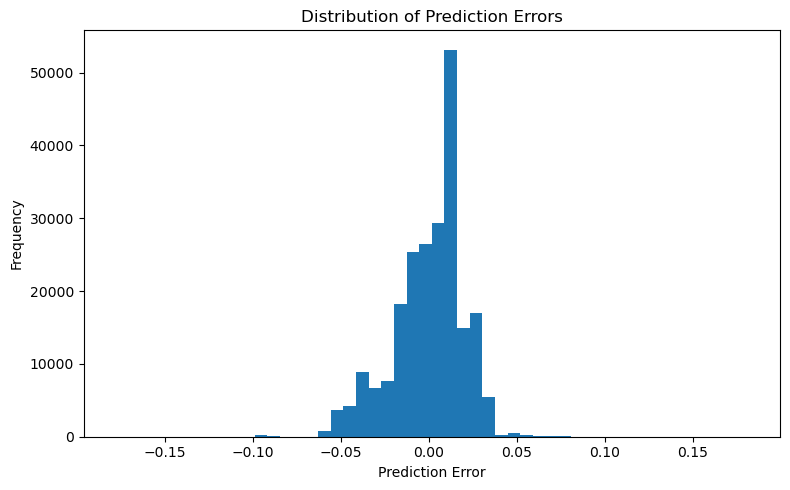

Figure saved to: ../reports/figures\error_distribution.png


In [8]:
plt.figure(figsize=(8, 5))

plt.hist(error_df["Error"], bins=50)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.tight_layout()

output_path = os.path.join(FIGURE_DIR, "error_distribution.png")
plt.savefig(output_path, dpi=300)

plt.show()

print(f"Figure saved to: {output_path}")

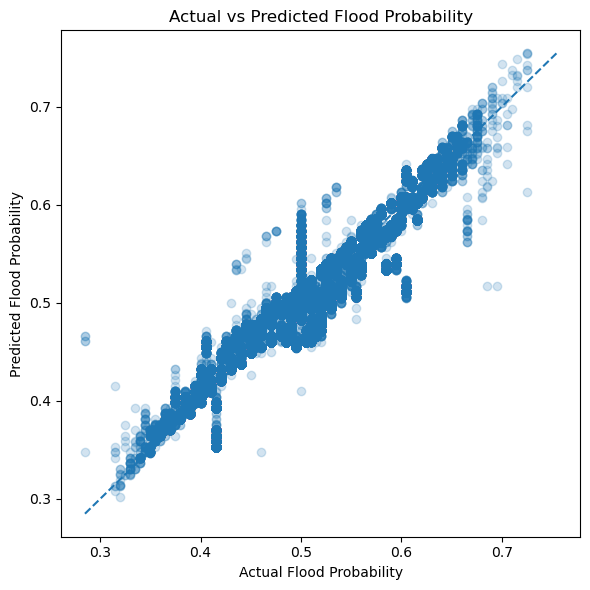

Figure saved to: ../reports/figures\actual_vs_predicted.png


In [9]:
plt.figure(figsize=(6, 6))

plt.scatter(
    error_df["Actual_FloodProbability"],
    error_df["Predicted_FloodProbability"],
    alpha=0.2
)

plt.xlabel("Actual Flood Probability")
plt.ylabel("Predicted Flood Probability")
plt.title("Actual vs Predicted Flood Probability")

min_value = min(
    error_df["Actual_FloodProbability"].min(),
    error_df["Predicted_FloodProbability"].min()
)

max_value = max(
    error_df["Actual_FloodProbability"].max(),
    error_df["Predicted_FloodProbability"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.tight_layout()

output_path = os.path.join(FIGURE_DIR, "actual_vs_predicted.png")
plt.savefig(output_path, dpi=300)

plt.show()

print(f"Figure saved to: {output_path}")

In [11]:
error_df["Flood_Level"] = pd.cut(
    error_df["Actual_FloodProbability"],
    bins=[0, 0.4, 0.6, 1.0],
    labels=["Low", "Medium", "High"]
)

level_error = error_df.groupby("Flood_Level", observed=False)["Absolute_Error"].mean()

level_error

Flood_Level
Low       0.011096
Medium    0.015825
High      0.018069
Name: Absolute_Error, dtype: float64

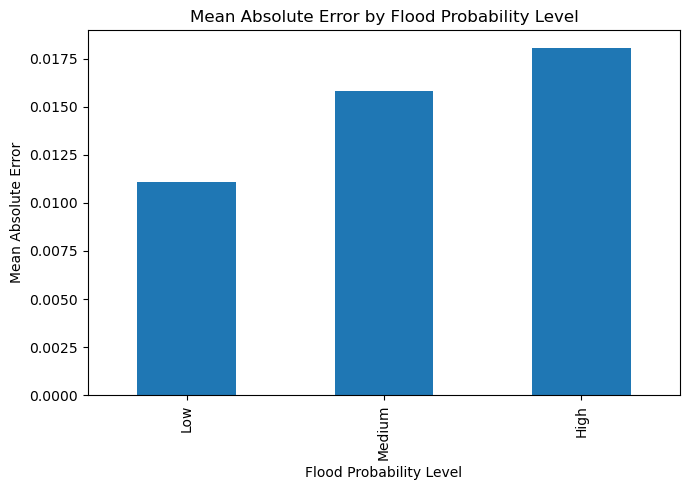

Figure saved to: ../reports/figures\error_by_flood_level.png


In [12]:
plt.figure(figsize=(7, 5))

level_error.plot(kind="bar")

plt.xlabel("Flood Probability Level")
plt.ylabel("Mean Absolute Error")
plt.title("Mean Absolute Error by Flood Probability Level")

plt.tight_layout()

output_path = os.path.join(FIGURE_DIR, "error_by_flood_level.png")
plt.savefig(output_path, dpi=300)

plt.show()

print(f"Figure saved to: {output_path}")

In [13]:
over_prediction = (error_df["Error"] > 0).mean()
under_prediction = (error_df["Error"] < 0).mean()

print(f"Overprediction ratio: {over_prediction:.4f}")
print(f"Underprediction ratio: {under_prediction:.4f}")

Overprediction ratio: 0.5634
Underprediction ratio: 0.4366


In [14]:
flood_level_summary = error_df.groupby("Flood_Level", observed=False).agg(
    Count=("Absolute_Error", "count"),
    Mean_Absolute_Error=("Absolute_Error", "mean"),
    Max_Absolute_Error=("Absolute_Error", "max"),
    Mean_Actual_FloodProbability=("Actual_FloodProbability", "mean"),
    Mean_Predicted_FloodProbability=("Predicted_FloodProbability", "mean")
)

flood_level_summary

,Count,Mean_Absolute_Error,Max_Absolute_Error,Mean_Actual_FloodProbability,Mean_Predicted_FloodProbability
Flood_Level,,,,,
Low,4545,0.011096,0.181359,0.384002,0.394724
Medium,212736,0.015825,0.112463,0.503557,0.503529
High,6311,0.018069,0.178108,0.622386,0.614703


In [15]:
FLOOD_LEVEL_SUMMARY_PATH = "../reports/flood_level_error_summary.csv"

flood_level_summary.to_csv(FLOOD_LEVEL_SUMMARY_PATH)

print(f"Flood level error summary saved to: {FLOOD_LEVEL_SUMMARY_PATH}")

Flood level error summary saved to: ../reports/flood_level_error_summary.csv


## Error Analysis Summary

The error distribution shows whether the model's prediction errors are centered around zero. If most errors are close to zero, the model is making small mistakes for most validation samples.

The actual vs predicted plot compares the model's predictions with the true FloodProbability values. Points closer to the diagonal line indicate better predictions.

The flood-level error analysis compares model performance across low, medium, and high flood probability ranges. This helps identify whether the model performs worse for certain risk levels.

The largest prediction errors suggest that the model may struggle with unusual feature combinations or extreme cases. Since this dataset does not include real spatial-temporal information, the results should be interpreted as a learning prototype rather than a real operational flood prediction system.